In [1]:
import sys
import os
# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))
import pandas as pd
from utils import (data_encoder, hyper_param_opt,
                   outlier_detection_by_clust,
                   weighted_distance_calculation,
                   outlier_detection_by_dist,
                   final_plot)
import pickle


In [15]:
dataset_name= 'german'

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 
data = X
data['class'] = y

In [18]:
data.head(3)

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Attribute1   1000 non-null   object
 1   Attribute2   1000 non-null   int64 
 2   Attribute3   1000 non-null   object
 3   Attribute4   1000 non-null   object
 4   Attribute5   1000 non-null   int64 
 5   Attribute6   1000 non-null   object
 6   Attribute7   1000 non-null   object
 7   Attribute8   1000 non-null   int64 
 8   Attribute9   1000 non-null   object
 9   Attribute10  1000 non-null   object
 10  Attribute11  1000 non-null   int64 
 11  Attribute12  1000 non-null   object
 12  Attribute13  1000 non-null   int64 
 13  Attribute14  1000 non-null   object
 14  Attribute15  1000 non-null   object
 15  Attribute16  1000 non-null   int64 
 16  Attribute17  1000 non-null   object
 17  Attribute18  1000 non-null   int64 
 18  Attribute19  1000 non-null   object
 19  Attribute20  1000 non-null  

## Imputation

In [20]:
from sklearn.impute import SimpleImputer

cols = data.columns
imp = SimpleImputer(strategy="most_frequent")
data = pd.DataFrame(imp.fit_transform(data))
data.columns = cols

## Encoding

In [21]:
encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, save=True)


In [27]:
encoded_data

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,0.0,2.0,4.0,4.0,142.0,4.0,4.0,3.0,2.0,0.0,...,0.0,48.0,2.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0
1,1.0,29.0,2.0,4.0,770.0,0.0,2.0,1.0,1.0,0.0,...,0.0,3.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0
2,3.0,8.0,4.0,7.0,390.0,0.0,3.0,1.0,2.0,0.0,...,0.0,30.0,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,26.0,2.0,3.0,848.0,0.0,3.0,1.0,2.0,2.0,...,1.0,26.0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
4,0.0,17.0,3.0,0.0,734.0,0.0,2.0,2.0,2.0,0.0,...,3.0,34.0,2.0,2.0,1.0,2.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3.0,8.0,2.0,3.0,310.0,0.0,3.0,2.0,1.0,0.0,...,0.0,12.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
996,0.0,21.0,2.0,1.0,661.0,0.0,2.0,3.0,0.0,0.0,...,1.0,21.0,2.0,1.0,0.0,3.0,0.0,1.0,0.0,0.0
997,3.0,8.0,2.0,4.0,69.0,0.0,4.0,3.0,2.0,0.0,...,2.0,19.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0
998,0.0,27.0,2.0,4.0,332.0,0.0,2.0,3.0,2.0,0.0,...,3.0,4.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,1.0


## DBSCAN HyperParameter Optimization

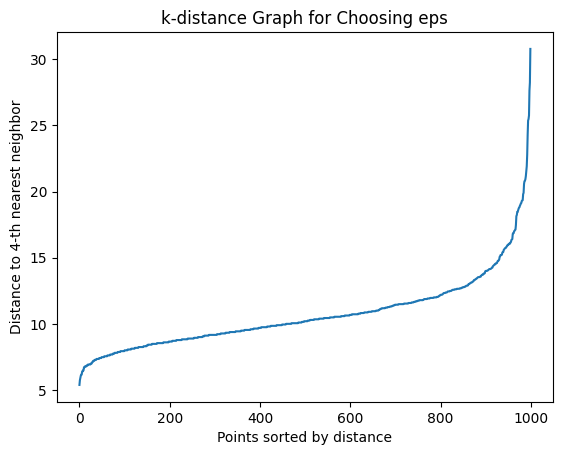

In [28]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 4  # Choose k as min_samples - 1
nbrs = NearestNeighbors(n_neighbors=k).fit(encoded_data) 
distances, _ = nbrs.kneighbors(encoded_data)
distances = np.sort(distances[:, k-1], axis=0)

plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {k}-th nearest neighbor")
plt.title("k-distance Graph for Choosing eps")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

encoded_data = StandardScaler().fit_transform(encoded_data)

In [29]:

    # GRID-SEARCH
hyper_param_opt.hyper_param_search(
    encoded_data,
    percentage_outliers=0.1,
    dataset_name=dataset_name,
    top_n=10,
    eps_values=np.linspace(10, 20, 10),
    min_samples_values=range(2, 10),
    metrics=['euclidean', 'manhattan'],
    save=True)

Processing DBSCAN parameters: 100%|██████████| 9600/9600 [03:40<00:00, 43.59it/s] 
/Users/navid/Documents/0_Research/0_venues/Privgen/utils/hyper_param_opt.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['ranking_score'] = (


,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
464,1,0.096,10.0,5,manhattan,kd_tree,50,2.0,0.144945
446,1,0.096,10.0,5,manhattan,ball_tree,40,2.0,0.144945
445,1,0.096,10.0,5,manhattan,ball_tree,40,1.0,0.144945
444,1,0.096,10.0,5,manhattan,ball_tree,40,NaN,0.144945
443,1,0.096,10.0,5,manhattan,ball_tree,30,2.0,0.144945
442,1,0.096,10.0,5,manhattan,ball_tree,30,1.0,0.144945
441,1,0.096,10.0,5,manhattan,ball_tree,30,NaN,0.144945
440,1,0.096,10.0,5,manhattan,ball_tree,20,2.0,0.144945
439,1,0.096,10.0,5,manhattan,ball_tree,20,1.0,0.144945
438,1,0.096,10.0,5,manhattan,ball_tree,20,NaN,0.144945


In [32]:
gs = pd.read_csv('../data/german_grid_search_results.csv')

In [33]:
gs.describe()

,num_clusters,percentage_outliers,eps,min_samples,leaf_size,p,silhouette_score
count,9600.00000,9600.000000,9600.000000,9600.000000,9600.000000,6400.000000,9600.000000
mean,1.04375,0.009150,15.000000,5.500000,30.000000,1.500000,-0.700538
std,0.30306,0.025345,3.191590,2.291407,14.142872,0.500039,0.519541
min,1.00000,0.000000,10.000000,2.000000,10.000000,1.000000,-1.000000
25%,1.00000,0.000000,12.222222,3.750000,20.000000,1.000000,-1.000000
50%,1.00000,0.000000,15.000000,5.500000,30.000000,1.500000,-1.000000
75%,1.00000,0.000750,17.777778,7.250000,40.000000,2.000000,-0.752319
max,4.00000,0.143000,20.000000,9.000000,50.000000,2.000000,0.264862


In [36]:
gs[gs['num_clusters'] > 2].sort_values(['silhouette_score','num_clusters', 'percentage_outliers'], ascending=[False, False, True])

,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
1020,3,0.033,11.111111,2,manhattan,auto,10,NaN,0.084077
1021,3,0.033,11.111111,2,manhattan,auto,10,1.0,0.084077
1022,3,0.033,11.111111,2,manhattan,auto,10,2.0,0.084077
1023,3,0.033,11.111111,2,manhattan,auto,20,NaN,0.084077
1024,3,0.033,11.111111,2,manhattan,auto,20,1.0,0.084077
...,...,...,...,...,...,...,...,...,...
115,4,0.079,10.000000,2,manhattan,brute,40,1.0,-0.009274
116,4,0.079,10.000000,2,manhattan,brute,40,2.0,-0.009274
117,4,0.079,10.000000,2,manhattan,brute,50,NaN,-0.009274
118,4,0.079,10.000000,2,manhattan,brute,50,1.0,-0.009274


## REMOVE DBSCAN OUTLIERS



In [37]:
outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=11, min_samples=2,
                                                        metric='manhattan', algorithm='auto',
                                                        leaf_size=10, dataset_name=dataset_name, p=1, plot=False)


Percentage of outliers removed: 3.70%
Number of clusters found: 3


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class,cluster
0,0.0,2.0,4.0,4.0,142.0,4.0,4.0,3.0,2.0,0.0,...,48.0,2.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0
1,1.0,29.0,2.0,4.0,770.0,0.0,2.0,1.0,1.0,0.0,...,3.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0
2,3.0,8.0,4.0,7.0,390.0,0.0,3.0,1.0,2.0,0.0,...,30.0,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0
3,0.0,26.0,2.0,3.0,848.0,0.0,3.0,1.0,2.0,2.0,...,26.0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,0
4,0.0,17.0,3.0,0.0,734.0,0.0,2.0,2.0,2.0,0.0,...,34.0,2.0,2.0,1.0,2.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,3.0,8.0,2.0,3.0,310.0,0.0,3.0,2.0,1.0,0.0,...,12.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
959,0.0,21.0,2.0,1.0,661.0,0.0,2.0,3.0,0.0,0.0,...,21.0,2.0,1.0,0.0,3.0,0.0,1.0,0.0,0.0,0
960,3.0,8.0,2.0,4.0,69.0,0.0,4.0,3.0,2.0,0.0,...,19.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0
961,0.0,27.0,2.0,4.0,332.0,0.0,2.0,3.0,2.0,0.0,...,4.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,1.0,0



## GET DISTRIBUTIONS


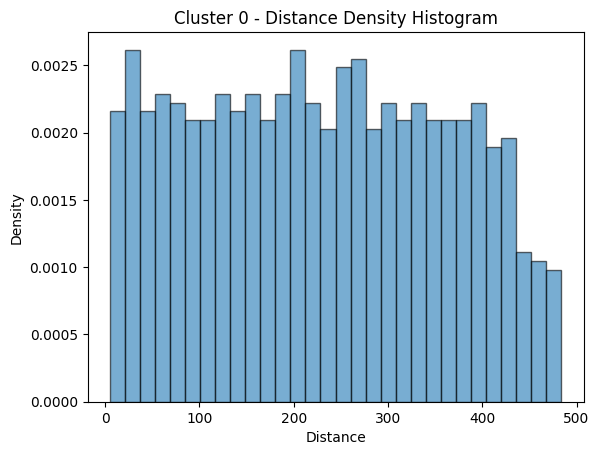

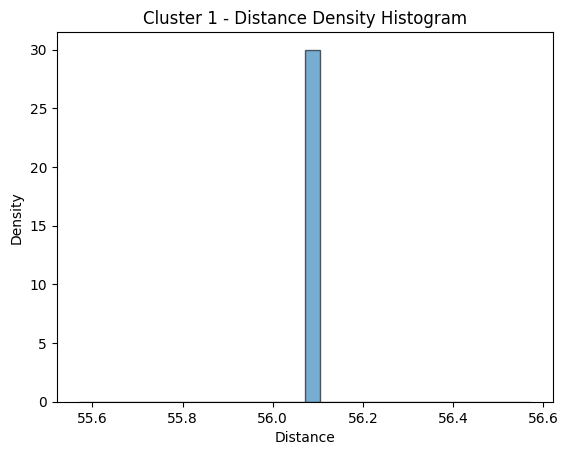

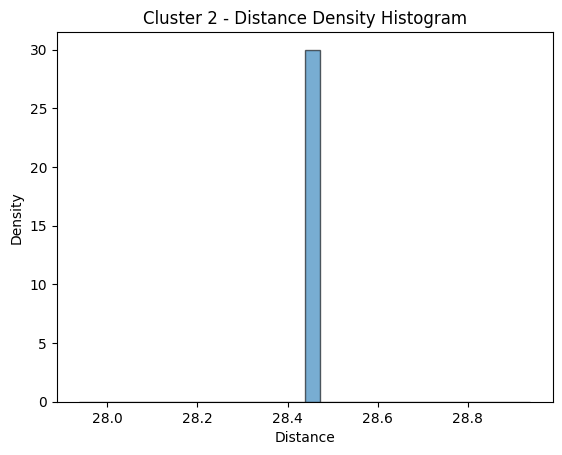

In [38]:
weighted_distance_calculation.calculate_plot_distance(dataset_name)



## REMOVE DISTANT OUTLIERS


In [39]:
threshold = {'0': 450}

outlier_detection_by_dist.filter_and_save_by_distance(
    dataset_name, threshold, plot=False)



## PLOT


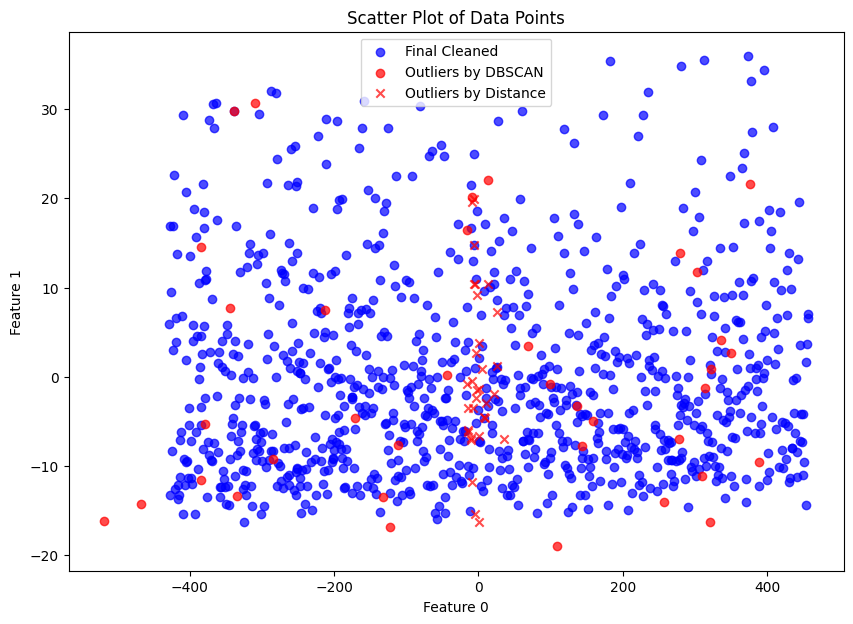

In [40]:
final_plot.plot_data_points(dataset_name)



## DECODING


In [41]:
decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)